In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from scipy.sparse import hstack

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Download necessary NLTK datasets
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rishi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rishi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rishi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

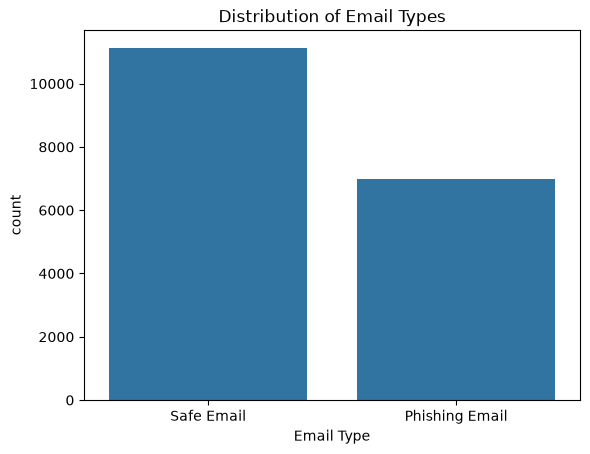

In [37]:
# Load dataset
df = pd.read_csv('Phishing_Email.csv')

# Handle missing or 'empty' values
df = df.dropna(subset=['Email Text', 'Email Type'])
df = df[df['Email Text'] != 'empty'].copy()

# Encode target variable: Safe Email = 0, Phishing Email = 1
df['Target'] = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

# Verify distribution
sns.countplot(x='Email Type', data=df)
plt.title('Distribution of Email Types')
plt.show()

In [38]:
# Extract metadata features BEFORE cleaning the text
# 1. Count of URLs
df['url_count'] = df['Email Text'].apply(lambda x: len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', str(x))))

# 2. Email Length (Character count)
df['email_length'] = df['Email Text'].apply(lambda x: len(str(x)))

# Normalize the metadata to prevent large numbers from dominating the model
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['url_count', 'email_length']] = scaler.fit_transform(df[['url_count', 'email_length']])

df[['Email Text', 'url_count', 'email_length', 'Target']].head()

,Email Text,url_count,email_length,Target
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0.000000,0.000060,0
1,the other side of * galicismos * * galicismo *...,0.000000,0.000028,0
2,re : equistar deal tickets are you still avail...,0.000000,0.000073,0
3,\nHello I am your hot lil horny toy.\n I am...,0.000319,0.000040,1
4,software at incredibly low prices ( 86 % lower...,0.000000,0.000026,1


In [39]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_email_text(text):
    text = str(text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Replace URLs and Email addresses with generic tokens (structural word patterns)
    text = re.sub(r'http\S+|www\.\S+', 'httpaddr', text)
    text = re.sub(r'\S+@\S+', 'emailaddr', text)
    
    # Remove punctuation and special characters (keep only letters)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Tokenize and lowercase
    tokens = nltk.word_tokenize(text.lower())
    
    # Remove stopwords and apply lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

# Apply NLTK cleaning pipeline
df['cleaned_text'] = df['Email Text'].apply(clean_email_text)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rishi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [40]:
from sklearn.feature_extraction import text

# 1. Grab scikit-learn's built-in English stopwords
sklearn_stopwords = set(text.ENGLISH_STOP_WORDS)

# 2. Add our specific dataset leakage words (Enron artifacts, Academic artifacts, and our regex tokens)
leak_words = {
    'enron', 'vince', 'louise', 'com', 'kaminski', 'shirley', # Enron specific
    'university', 'linguistics', 'language', 'edu', 'question',     # Academic specific
    'httpaddr', 'http', 'url', 'pm', 'date', 'file', 'attached', 'wrote', 'thanks','click',
}
custom_stopwords = sklearn_stopwords.union(leak_words)

# 3. Initialize TF-IDF with the custom stop words list
tfidf = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2), 
    sublinear_tf=True,
    stop_words=list(custom_stopwords) # Forces the vectorizer to ignore these leaked words
)

X_text = tfidf.fit_transform(df['cleaned_text'])

# Combine TF-IDF sparse matrix with our structural metadata features
X_metadata = df[['url_count', 'email_length']].values
X_combined = hstack((X_text, X_metadata))

y = df['Target'].values

print(f"Shape of text features: {X_text.shape}")
print(f"Shape of combined features: {X_combined.shape}")

Shape of text features: (18101, 5000)
Shape of combined features: (18101, 5002)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

In [42]:
results = {}

def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    results[model_name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred))
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2225
           1       0.95      0.94      0.95      1396

    accuracy                           0.96      3621
   macro avg       0.96      0.96      0.96      3621
weighted avg       0.96      0.96      0.96      3621



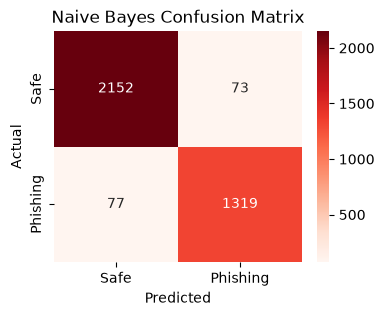

In [43]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

evaluate_model('Naive Bayes', y_test, y_pred_nb)

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      2225
           1       0.97      0.92      0.94      1396

    accuracy                           0.96      3621
   macro avg       0.96      0.95      0.95      3621
weighted avg       0.96      0.96      0.96      3621



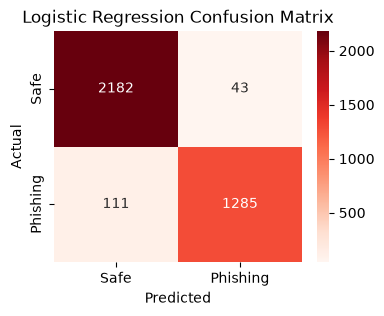

In [44]:
log_reg = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

evaluate_model('Logistic Regression', y_test, y_pred_log)

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      2225
           1       0.97      0.85      0.91      1396

    accuracy                           0.93      3621
   macro avg       0.94      0.92      0.93      3621
weighted avg       0.94      0.93      0.93      3621



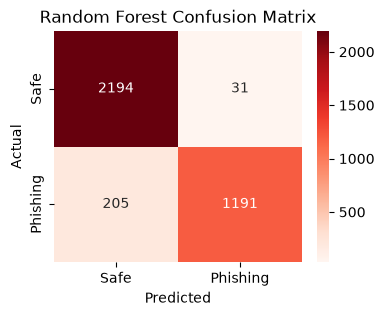

In [45]:
rf = RandomForestClassifier(n_estimators=100, max_depth=30, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

evaluate_model('Random Forest', y_test, y_pred_rf)

=== Simple Neural Network ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2225
           1       0.96      0.96      0.96      1396

    accuracy                           0.97      3621
   macro avg       0.97      0.97      0.97      3621
weighted avg       0.97      0.97      0.97      3621



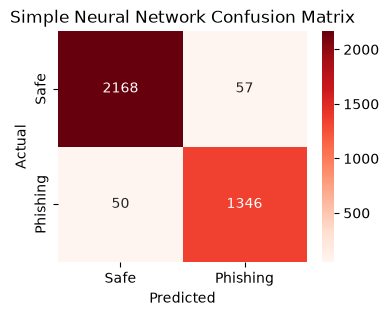

In [50]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=200, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

evaluate_model('Simple Neural Network', y_test, y_pred_mlp)

In [47]:
# Evaluate on the training set to check for an overfitting gap
for name, model in [('Naive Bayes', nb), ('Logistic Regression', log_reg), ('Random Forest', rf), ('Simple Neural Network', mlp)]:
    train_preds = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    test_preds = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    print(f"{name} -> Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Naive Bayes -> Train Acc: 0.9558 | Test Acc: 0.9586
Logistic Regression -> Train Acc: 0.9698 | Test Acc: 0.9575
Random Forest -> Train Acc: 0.9563 | Test Acc: 0.9348
Simple Neural Network -> Train Acc: 0.9939 | Test Acc: 0.9705


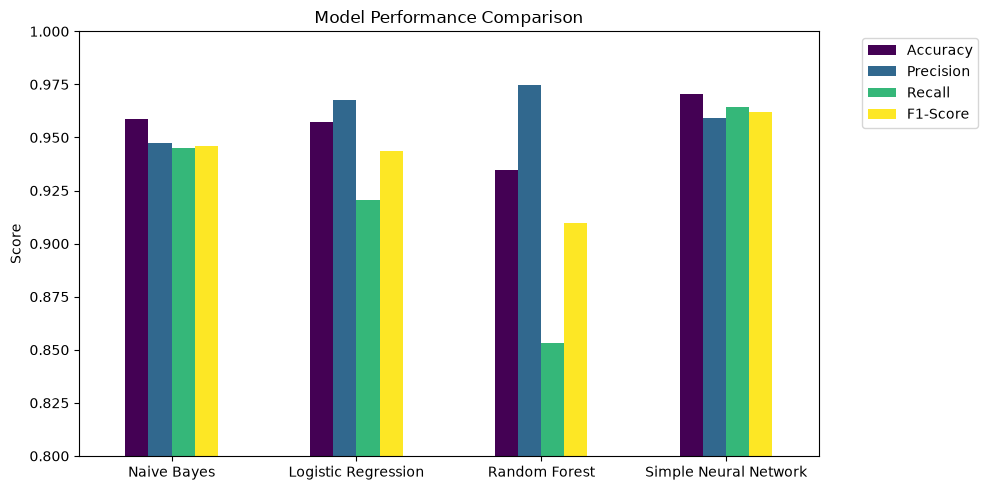

C:\Users\rishi\AppData\Local\Temp\ipykernel_33596\4093795906.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_phishing, palette='Reds_r')


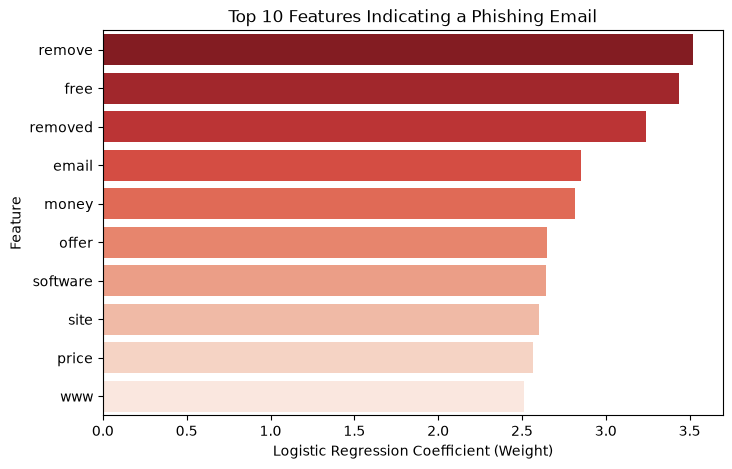

In [48]:
# 1. Plot Performance Comparison
df_results = pd.DataFrame(results).T
df_results.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Extract and Plot Feature Importance (from Logistic Regression)
feature_names = tfidf.get_feature_names_out().tolist() + ['url_count', 'email_length']
coefficients = log_reg.coef_[0]

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
top_phishing = feat_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=top_phishing, palette='Reds_r')
plt.title('Top 10 Features Indicating a Phishing Email')
plt.xlabel('Logistic Regression Coefficient (Weight)')
plt.ylabel('Feature')
plt.show()

In [49]:
import pandas as pd

# Extract feature names from the TF-IDF vectorizer
# 2. Extract and Plot Feature Importance (from Logistic Regression)
feature_names = tfidf.get_feature_names_out().tolist() + ['url_count', 'email_length']
coefficients = log_reg.coef_[0]

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})

# Get the strongest predictors for both classes
top_phishing = feat_imp.sort_values(by='Importance', ascending=False).head(10)
top_not_phishing = feat_imp.sort_values(by='Importance', ascending=True).head(20)

print("--- Top 20 Words Predicting Phishing Mail ---")
print(top_phishing.to_string(index=False))

print("\n--- Top 20 Words Predicting not Phishing Mail ---")
print(top_not_phishing.to_string(index=False))

--- Top 20 Words Predicting Phishing Mail ---
 Feature  Importance
  remove    3.522124
    free    3.434721
 removed    3.241709
   email    2.849777
   money    2.814721
   offer    2.649438
software    2.643109
    site    2.602151
   price    2.566831
     www    2.511869

--- Top 20 Words Predicting not Phishing Mail ---
   Feature  Importance
    discus   -2.513242
       sep   -2.417505
     group   -2.178372
   houston   -2.176454
   english   -2.141309
conference   -2.084410
  schedule   -2.062589
     issue   -2.049257
        cc   -1.986494
       hpl   -1.978132
       rpm   -1.911072
  research   -1.900215
   meeting   -1.897450
      john   -1.878937
    august   -1.850738
  employee   -1.827881
 emailaddr   -1.819459
   comment   -1.814541
 september   -1.784679
  let know   -1.774041


=== Ensemble Voting Classifier ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2225
           1       0.98      0.96      0.97      1396

    accuracy                           0.97      3621
   macro avg       0.97      0.97      0.97      3621
weighted avg       0.97      0.97      0.97      3621



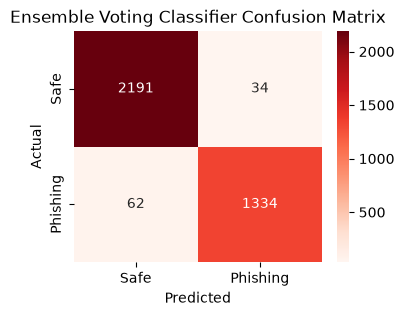

In [51]:
from sklearn.ensemble import VotingClassifier

# Initialize the Voting Classifier using our previously trained models
# We use voting='soft' to average their probability confidence scores
voting_clf = VotingClassifier(
    estimators=[
        ('Naive Bayes', nb),
        ('Logistic Regression', log_reg),
        ('Random Forest', rf),
        ('Neural Network', mlp)
    ],
    voting='soft',
    n_jobs=-1
)

# Fit the ensemble on the training data
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

# Evaluate the ultimate ensemble model
evaluate_model('Ensemble Voting Classifier', y_test, y_pred_voting)